# MetaTune walkthrough: blood-cell segmentation (BCCD)

This notebook reproduces one task of the paper end to end, from the public data to the reported numbers:

1. **Setup**: environment and the SAM ViT-B checkpoint.
2. **Data**: download BCCD from Kaggle and organize it.
3. **Split**: the exact 4 labeled images and their D₁/D₂ assignment.
4. **Training**: meta-finetune SAM with MetaTune on those 4 images.
5. **Inference and evaluation**: Dice on the 159 test images, plus exported masks.
6. **Reported numbers**: evaluate the released checkpoints behind Figure 2 (MetaTune) and Figure 3 (SAMed).
7. **Baselines**: where to go next.

Run the cells top to bottom from the repository root. On one NVIDIA A100 the whole notebook takes about 15 minutes, most of it spent downloading. The same checks are available non-interactively as `python scripts/verify_bccd.py --data_root $DATA_ROOT --download_checkpoints --retrain`.

## 1. Setup

Create the environment once from the repository root (`conda env create -f environment.yml && conda activate metatune`) and start Jupyter from that environment. The paths below can be changed through environment variables; the defaults match [REPRODUCE.md](REPRODUCE.md).

In [1]:
import os, re, subprocess, sys, time
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image

DATA_ROOT = os.path.abspath(os.environ.get("DATA_ROOT", "../datasets"))      # data goes to $DATA_ROOT/blood-cell
SAM_CKPT = os.path.abspath(os.environ.get("SAM_CKPT", "./checkpoints/sam_vit_b_01ec64.pth"))
ZENODO_DIR = os.path.abspath(os.environ.get("ZENODO_DIR", "./zenodo"))       # released checkpoints
OUTPUT = os.path.abspath("./output_walkthrough")
GPU = int(os.environ.get("GPU", 0))
PYTHON = sys.executable

TRAIN_IMAGES = f"{DATA_ROOT}/blood-cell/train/Images"
TEST_IMAGES = f"{DATA_ROOT}/blood-cell/test/Images"

print("python     ", sys.version.split()[0])
print("torch      ", torch.__version__, "| CUDA", torch.version.cuda, "| cuDNN", torch.backends.cudnn.version())
print("GPU        ", torch.cuda.get_device_name(GPU))

python      3.10.18
torch       2.5.1+cu121 | CUDA 12.1 | cuDNN 90100
GPU         NVIDIA A100 80GB PCIe


In [2]:
# SAM ViT-B weights (375 MB), the foundation model MetaTune finetunes.
if not os.path.exists(SAM_CKPT):
    os.makedirs(os.path.dirname(SAM_CKPT), exist_ok=True)
    torch.hub.download_url_to_file("https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth", SAM_CKPT)
print(SAM_CKPT, f"{os.path.getsize(SAM_CKPT) / 1e6:.0f} MB")

/data2/li/workspace/MetaTune/checkpoints/sam_vit_b_01ec64.pth 375 MB


## 2. Data

The [Blood Cell Segmentation Dataset](https://www.kaggle.com/datasets/jeetblahiri/bccd-dataset-with-mask) (MIT license) ships as `train/{original,mask}` and `test/{original,mask}`. `scripts/prepare_bccd.py`:
- downloads it with the Kaggle API (this needs `pip install kaggle` and a token in `~/.kaggle/kaggle.json`; or pass `--zip` with a manual download);
- renames the folders to `Images/` and `Masks/`;
- converts the 119 JPEG images to PNG, as in our experiments;
- checks the result against the manifests in `splits/bccd/`.

The script can be re-run safely; files that already exist are skipped.

In [3]:
!{PYTHON} scripts/prepare_bccd.py --data_root {DATA_ROOT}

OK: /tmp/claude-1004/-data2-li-workspace-SAMed/b8ef0816-c77b-4dc8-94bd-1aa6cc69391e/scratchpad/wt_nb_data/blood-cell has 1169 train / 159 test images and contains every image listed in splits/bccd/.


## 3. The training split

MetaTune is trained on **4 labeled images**. The meta-finetuning splits them into two halves:
- **D₁** (`non_meta_D1.txt`) updates the *non-meta* parameters (LoRA layers and mask decoder).
- **D₂** (`meta_D2.txt`) updates the *meta* parameter, SAM's learnable prompt embedding.

By default the loader would take the first 4 files in directory-listing order, which differs between filesystems; that is why an independent rerun can end up training on different images. This notebook never relies on that order: `SPLIT_DIR` names the manifest, and every image used below for training and for evaluation is read from `splits/bccd/`. The manifest lists the images of one of the three runs averaged in Figure 2.

D1 (non-meta): ['7521ec48-57b5-48a8-a5d6-8280ad5da19c.png', '434523fd-d4d9-4961-a7c2-d71d6ae68e13.png']
D2 (meta):     ['5836500a-221e-40ca-a8be-caaa37f7d300.png', '334bf865-e3fb-4200-bd53-d9ff5808ed9f.png']
test images:   159 from splits/bccd/test.txt
all manifest images present in /tmp/claude-1004/-data2-li-workspace-SAMed/b8ef0816-c77b-4dc8-94bd-1aa6cc69391e/scratchpad/wt_nb_data


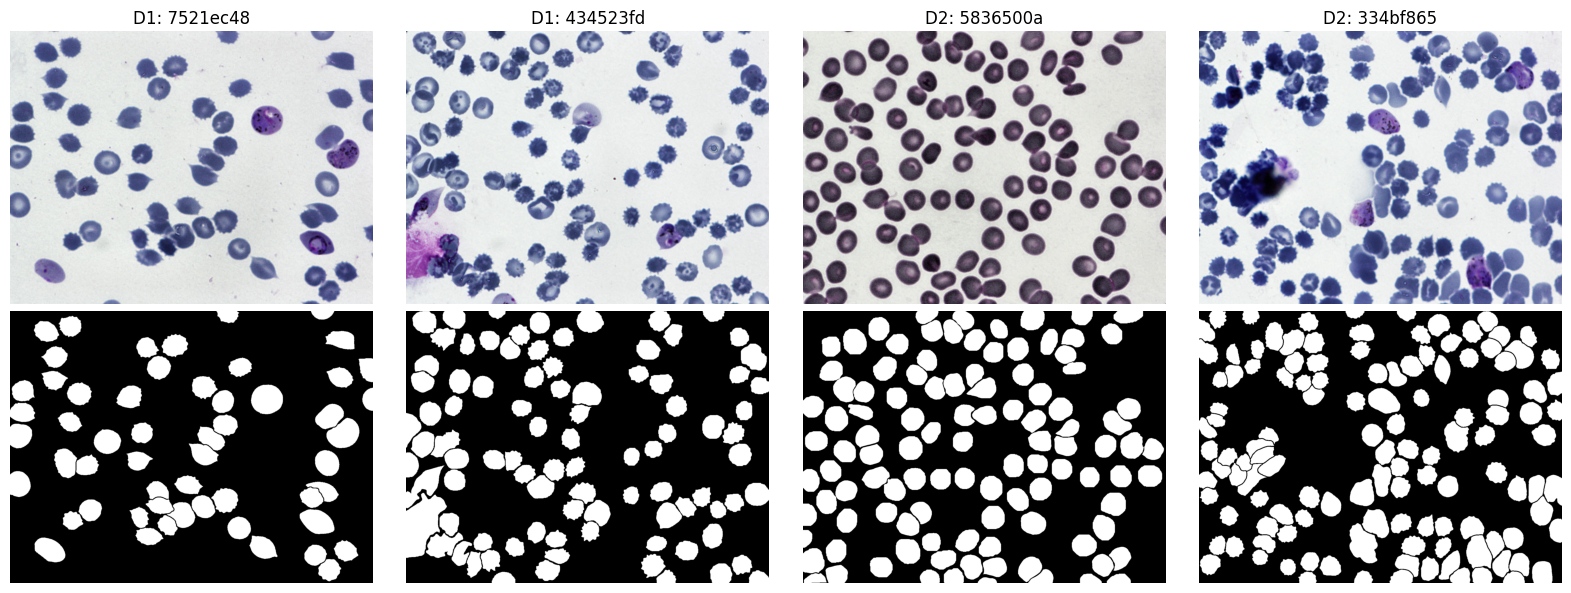

In [4]:
SPLIT_DIR = "splits/bccd/run_1"
d1 = open(f"{SPLIT_DIR}/non_meta_D1.txt").read().split()
d2 = open(f"{SPLIT_DIR}/meta_D2.txt").read().split()
print("D1 (non-meta):", d1)
print("D2 (meta):    ", d2)
test_names = open("splits/bccd/test.txt").read().split()
print("test images:  ", len(test_names), "from splits/bccd/test.txt")

# The prepared data must contain exactly the images the manifests name.
assert all(os.path.exists(f"{TRAIN_IMAGES}/{n}") for n in d1 + d2)
assert sorted(os.listdir(TEST_IMAGES)) == sorted(test_names)
print("all manifest images present in", DATA_ROOT)

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for col, name in enumerate(d1 + d2):
    axes[0, col].imshow(Image.open(f"{TRAIN_IMAGES}/{name}"))
    axes[0, col].set_title(("D1: " if name in d1 else "D2: ") + name[:8])
    axes[1, col].imshow(Image.open(f"{TRAIN_IMAGES.replace('Images', 'Masks')}/{name}").convert("L"), cmap="gray")
for ax in axes.flat:
    ax.axis("off")
plt.tight_layout()

## 4. Training

`train.sh` runs first-order bilevel optimization for 100 epochs. Each iteration has two steps:
1. a gradient step on the non-meta parameters using a D₁ image;
2. a step on the prompt embedding using a D₂ image.

`SPLIT_DIR` fixes which images are used, so `--num_data` plays no role here. The remaining settings are those of the corresponding run in Figure 2, as recorded in its `config.txt` (printed in Section 6): learning rate 5e-3 for both parameter groups, LoRA rank 4 on the mask decoder, and input size 256. The checkpoint with the best Dice on D₂ is saved as `best.pth`. This takes about 5 minutes on an A100.

In [5]:
env = dict(os.environ, PYTHON=PYTHON, DATASET="blood", TRAIN_IMAGES=TRAIN_IMAGES,
           BASE_LR="5e-3", PROMPT_LR="5e-3", SPLIT_DIR=SPLIT_DIR,
           GPU=str(GPU), SAM_CKPT=SAM_CKPT, OUTPUT=OUTPUT)
t0 = time.time()
log = subprocess.run(["bash", "train.sh"], env=env, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, check=True).stdout
print(f"finished in {(time.time() - t0) / 60:.1f} min")

run_dir = sorted(d for d in os.listdir(OUTPUT) if d.startswith("blood4_auto_first"))[-1]
LORA_CKPT = f"{OUTPUT}/{run_dir}/best.pth"
print("checkpoint:", LORA_CKPT)
cfg = dict(line.strip().split(": ", 1) for line in open(f"{OUTPUT}/{run_dir}/config.txt") if ": " in line)
print("split_dir recorded in config.txt:", cfg["split_dir"])
valid = [float(v) for v in re.findall(r"valid score : ([0-9.]+)", log)]
print(f"D2 Dice: epoch 1 {valid[0]:.3f} -> epoch 100 {valid[-1]:.3f} (best {max(valid):.3f})")

finished in 3.9 min
checkpoint: /data2/li/workspace/MetaTune/output_walkthrough/blood4_auto_first_img256_20260921-161738/best.pth
split_dir recorded in config.txt: splits/bccd/run_1
D2 Dice: epoch 1 0.000 -> epoch 100 0.859 (best 0.876)


## 5. Inference and evaluation

`inference.sh` predicts a mask for every image in `<DATA_ROOT>/blood-cell/test/Images`, checked against `splits/bccd/test.txt` above, and reports the mean Dice over the 159 images. The Dice is computed on the foreground class after an argmax over the model's two output channels. `SAVE_PREDICTIONS=1` also writes one binary PNG per image.

**Expected:** a Dice of about 0.871. We obtain 0.8711 with the released code (PyTorch 2.5.1, CUDA 12.1, A100); the paper reports 0.8710 for this run. Other GPUs or library versions can move the third or fourth decimal.

In [6]:
def evaluate(lora_ckpt, save_dir=None):
    env = dict(os.environ, PYTHON=PYTHON, DATASET="blood", VOLUME_PATH=TEST_IMAGES, LORA_CKPT=lora_ckpt,
               GPU=str(GPU), SAM_CKPT=SAM_CKPT, SAVE_PREDICTIONS="1" if save_dir else "0",
               OUTPUT_DIR=save_dir or f"{OUTPUT}/predictions_unused")
    out = subprocess.run(["bash", "inference.sh"], env=env, capture_output=True, text=True, check=True).stdout
    return float(re.search(r"Test dice score: ([0-9.]+)", out).group(1))

PRED_DIR = f"{OUTPUT}/predictions"
dice = evaluate(LORA_CKPT, save_dir=PRED_DIR)
print(f"Test Dice (159 images): {dice:.4f}   reported: 0.8710")

Test Dice (159 images): 0.8711   reported: 0.8710


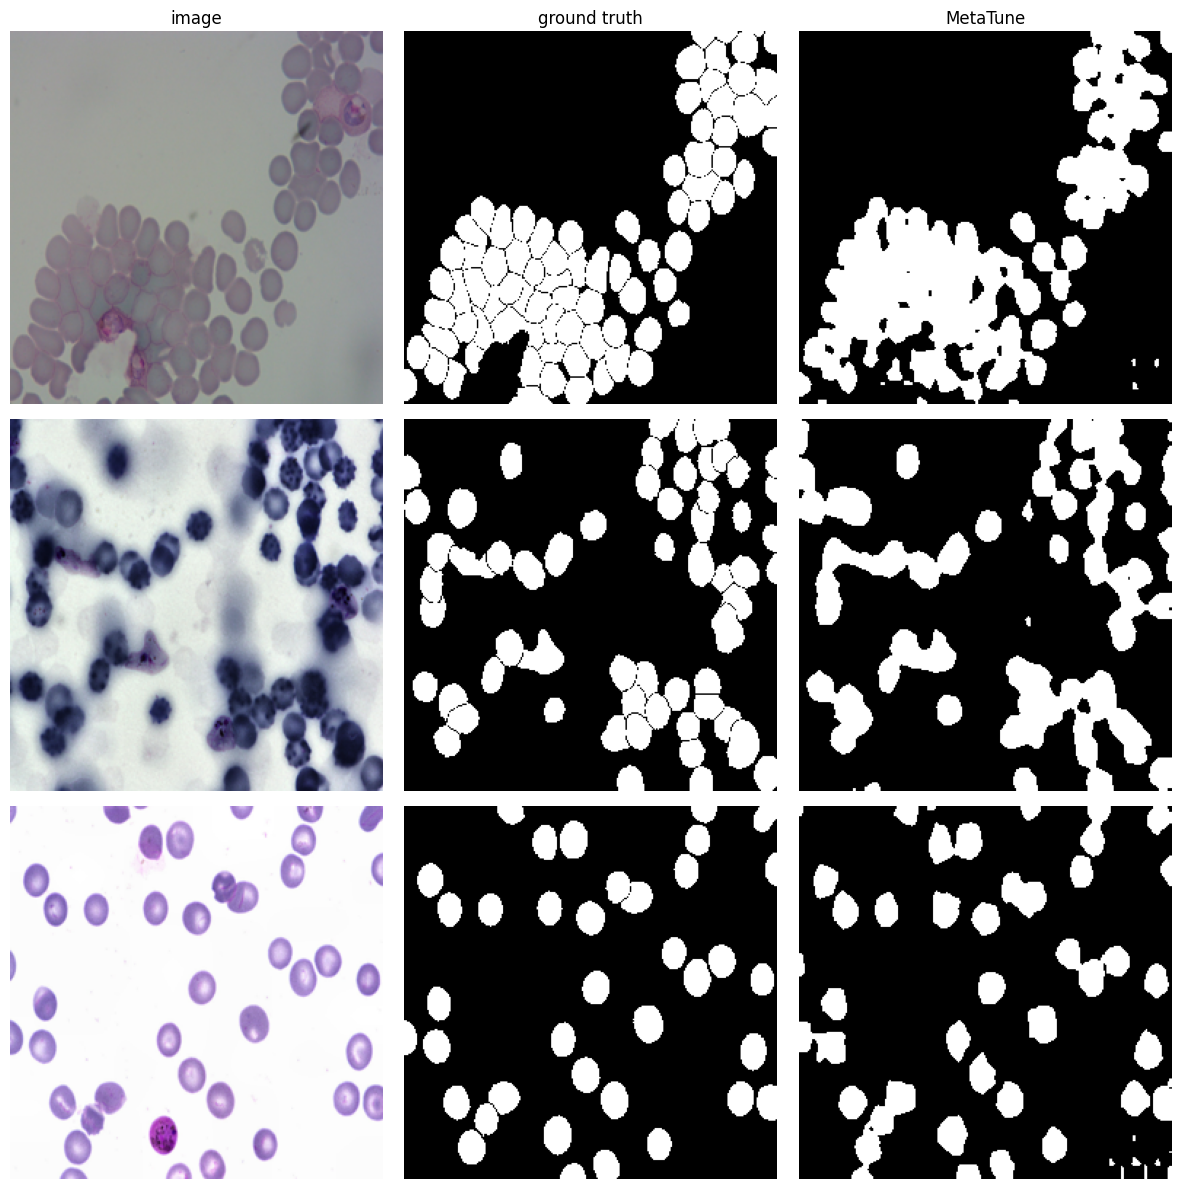

In [7]:
# Three test images: input, ground truth, MetaTune prediction (masks are 256 x 256).
examples = sorted(test_names)[:3]      # from splits/bccd/test.txt
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
for row, name in enumerate(examples):
    axes[row, 0].imshow(Image.open(f"{TEST_IMAGES}/{name}").resize((256, 256)))
    axes[row, 1].imshow(Image.open(f"{TEST_IMAGES.replace('Images', 'Masks')}/{name}").convert("L").resize((256, 256), Image.NEAREST), cmap="gray")
    axes[row, 2].imshow(Image.open(f"{PRED_DIR}/{name}"), cmap="gray")
for ax, title in zip(axes[0], ["image", "ground truth", "MetaTune"]):
    ax.set_title(title)
for ax in axes.flat:
    ax.axis("off")
plt.tight_layout()

## 6. The reported numbers

The BCCD bar in Figure 2 (Dice 0.87) is the mean of three MetaTune runs. Their checkpoints, and that of the SAMed baseline in Figure 3, are on Zenodo ([10.5281/zenodo.20517421](https://doi.org/10.5281/zenodo.20517421)). Each is bundled with the `config.txt` of the run that produced it. Inference is deterministic, so evaluating them reproduces the reported values. `scripts/verify_bccd.py` downloads the archive (about 716 MB), unpacks the blood-cell checkpoints, and compares each score with the paper.

In [8]:
!{PYTHON} scripts/verify_bccd.py --data_root {DATA_ROOT} --checkpoints_dir {ZENODO_DIR} --download_checkpoints --sam_ckpt {SAM_CKPT} --gpu {GPU}


Check                                 Reported  Obtained  Tolerance  Result
MetaTune run 1 (Fig. 2)                 0.8649    0.8649     ±0.002  PASS
MetaTune run 2 (Fig. 2)                 0.8704    0.8705     ±0.002  PASS
MetaTune run 3 (Fig. 2)                 0.8710    0.8711     ±0.002  PASS
SAMed baseline (Fig. 3)                 0.8549    0.8551     ±0.002  PASS
MetaTune mean of 3 runs (Fig. 2)        0.8700    0.8688  rounds to  PASS


In [9]:
# The configurations shipped with the released checkpoints. These runs predate --split_dir and selected
# their images by listing order; splits/bccd/ records the images of the run retrained above.
root = f"{ZENODO_DIR}/metatune_v1/metatune_zenodo_v1/semantic_main"
for run in sorted(os.listdir(root)):
    cfg = dict(line.strip().split(": ", 1) for line in open(f"{root}/{run}/config.txt") if ": " in line)
    print(f"{run:<50} base_lr={cfg['base_lr']:<6} prompt_base_lr={cfg['prompt_base_lr']}")

blood4_auto_first_img256_20240826-055350_8649      base_lr=0.005  prompt_base_lr=0.001
blood4_auto_first_img256_20241030-202935_8704      base_lr=0.005  prompt_base_lr=0.005
blood4_auto_first_img256_20241030-203538           base_lr=0.005  prompt_base_lr=0.005


## 7. Baselines

- **SAMed** is trained with this repository (`train_vanilla.py`); the command is in [BASELINES.md §4](BASELINES.md#4-samed). Its released BCCD checkpoint is evaluated in Section 6 above.
- **PerSAM-F and Matcher** (Figure 7) ship in `baselines/` and are launched with `scripts/launch_persam_gpu0.sh` and `scripts/launch_matcher_gpu0.sh`.
- **DeepLabV3, UNet, vanilla SAM, MedSA, uSAM and HSNet** build on their public implementations. [BASELINES.md](BASELINES.md) gives the upstream commit, every modification, the command and the evaluation protocol for each.

## Summary

| Step | Command | Output |
|---|---|---|
| Data | `python scripts/prepare_bccd.py --data_root $DATA_ROOT` | `$DATA_ROOT/blood-cell/{train,test}/{Images,Masks}` |
| Train | `SPLIT_DIR=splits/bccd/run_1 BASE_LR=5e-3 PROMPT_LR=5e-3 DATASET=blood TRAIN_IMAGES=... bash train.sh` | `output/blood4_auto_first_img256_<time>/best.pth` |
| Evaluate | `DATASET=blood VOLUME_PATH=... LORA_CKPT=... bash inference.sh` | Test Dice ≈ 0.871 |
| Verify | `python scripts/verify_bccd.py --data_root $DATA_ROOT --download_checkpoints --retrain` | PASS/FAIL table against the paper |